# Data Mining Assingment 2 - Izaak King, kingi@rpi.edu 
Attached is my submission for assignment 2. 


## Data Parsing

We start by using Pandas Library to parse our data file, then we use NumPy to create our Data Matrix

In [43]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

rawData = pd.read_csv("wdbc.data")          #Use Pandas Library to parse inital data file, store in Data frame
diagnosisData = (rawData.iloc[ : , 1]).to_numpy()          #The Second column is the Diagosis Variable, which we will use for plotting
dataMatrix = (rawData.iloc[ : , 2: ]).to_numpy()           #Columns 3-32 are saved and added created into a Data Matrix using NumPy. Column 1, Patient ID, is disregarded.

## Eigenvectors and Principal Components

We compute the first two eigenvectors and their corresponding eigenvalues of the covariance (d x d) matrix, Sigma, by implementing the Power-Iteration method. We start by generating x0 (our first xt), a d x 2 random matrix. Following this, our algorithm is as follows: We orthogonalize the second column with respect to the first, then normalize both columns. Finally we do our left multiplication of sigma and xt to get xt1, the next iteration in our method. We continue with this method until we see it converge. We determine the method has converged pnce the Frobenius norm between xt1 and xt is less than epsilon. For this assignment, we take epsilon = 10 ^ -6. Ultimately once our method converges xt will contain the first two eigenvectors with largest eigenvalues.

During this method we can also get the corresponding eigenvalues for the eigenvectors we are approximating. During each iteration, we take the max valued element, and compute the ratio of the element's value before and after the multiplication update. This ratio gives us our estimate for the eigenvalue. We record these all in a list for plotting purposes later.

In [44]:
sigma = np.cov(dataMatrix, rowvar=False)            #Get our covariance matrix, sigma
randMatrix = np.random.randn(sigma.shape[1], 2)     #Use numpy random to generate our d x 2 starting matrix

lambda1_list = []                                   #Initialize lists for storing eigenvalue iterations
lambda2_list = []

xt = randMatrix                                     #Our first iteration uses the random matrix we generated
epsi = 10 ** -6                                     #Set our epsilon
convergence = 10000                                 #Set set our convergence value to an arbitrary much higher value, this will be updated accordingly

while convergence > epsi:           #We iterate through until our convergence value is less than epsilon
    v1 = xt[:, 0]                   #Take v1 and v2 as our unorthogonalized and unnormalized vectors
    v2 = xt[:, 1]

    projectionScalar = np.dot(v2, v1) / np.dot(v1, v1)         #We compute our new orthogonalized vector, v2, with respect to v1
    projection = projectionScalar * v1 
    v2 = v2 - projection
    
    v1_normalized = v1 / np.linalg.norm(v1)                   #We normalize both v1 and v2, set up our orthonormal matrix
    v2_normalized = v2 / np.linalg.norm(v2)
    orthonormalMatrix = np.column_stack((v1_normalized, v2_normalized))
    
    xt1 = sigma @ orthonormalMatrix                         #Perform our multiply with sigma dnd our orthonormal matrix, compute the convergence
    convergence = np.linalg.norm(xt1 - xt)

    u1 = xt[:,0]                                           #We take the projected eigenvectors from xt, u1 and u2
    u2 = xt[:,1]
    
    index1 = np.argmax(np.abs(u1))                          #We get the index of our max values, using this to compare the value before and after multiplying by sigma
    index2 = np.argmax(np.abs(u2))
    lambda1 = (sigma @ u1)[index1] / u1[index1]             #We can get our estimated eigenvalues by computing the ratio before and after multiplying by sigma
    lambda2 = (sigma @ u2)[index2] / u2[index2]
    lambda1_list.append(lambda1)                            #We add each eigenvalue to its list, used for plotting
    lambda2_list.append(lambda2)     
     
    xt = xt1                                                #Continue our iteration by setting xt = xt1 for next round




## Eigenvectors and Eigenvalues comparisons

Now we have obtained our first two eigenvectors u1, u2, and their corresponding eigenvalues from our power iteration algorithm. Now, we verify our answer using numpy linalg.eigh function.

Based on our output, we can conclude the algorithm is working correctly.

In [45]:
npEigenValues, npEigenVectors = np.linalg.eigh(sigma)       #Compute eigenvalues and eigenvectors using NumPy

print("Estimated eigenvectors and eigenvalues:")          #Use print statements to compare our estimated vectors and values to our computed ones
print(f"\nu1 = {u1}")
print(f"\nlambda1 = {lambda1}")
print(f"\nu2 = {u2}")
print(f"\nlambda2 = {lambda2}")
print("\n\nActual eigenvalues:")
print(f"\nu1 = {npEigenVectors[:, -1]}")
print(f"\nlambda1 = {npEigenValues[-1]}")
print(f"\nu2 = {npEigenVectors[:, -2]}")
print(f"\nlambda2 = {npEigenValues[-2]}")

Estimated eigenvectors and eigenvalues:

u1 = [-2.25334129e+03 -9.94747055e+02 -1.55311770e+04 -2.29062356e+05
 -1.83827243e+00 -1.76613713e+01 -3.59953758e+01 -2.10409403e+01
 -3.02191311e+00  1.19822713e+00 -1.38063924e+02  2.82993865e+01
 -9.82473764e+02 -2.45425963e+04  3.56837944e-01 -2.40546078e+00
 -3.89922088e+00 -1.44953314e+00  5.71047493e-01  4.29043881e-02
 -3.16207117e+03 -1.38061974e+03 -2.18286742e+04 -3.76459597e+05
 -2.79223021e+00 -4.41783779e+01 -7.41970700e+01 -3.24399854e+01
 -7.60717271e+00 -6.45153552e-01]

lambda1 = 442188.20291908906

u2 = [ 6.68650516e+01 -2.71469426e+01  4.53848335e+02  6.10039171e+03
 -9.93635970e-02  4.63852210e-02  6.11139446e-01  3.61491871e-01
 -1.57010801e-01 -1.07963814e-01 -2.10453503e-01  2.44312633e+00
  7.73819430e+00  8.24488035e+01  1.12188623e-02  1.02591999e-01
  2.16705538e-01  6.88125559e-02  9.58522742e-02  3.49868915e-03
 -3.84854164e+00 -1.03140503e+02  8.38099856e+00 -3.73639514e+03
 -5.51248126e-01 -1.72433060e+00 -1.160

## Projection of estimates of lambda 1 and lambda 2 as a function of t.

Now that we have our eigenvalue estimates, as well as our list of iterations, we plot both of these against t, our number of iterations. We create two plots, one for our first eigenvalue lambda 1, and one for our second eigenvalue, lambda 2.

We can see the large variation in values until our method begins to converge.

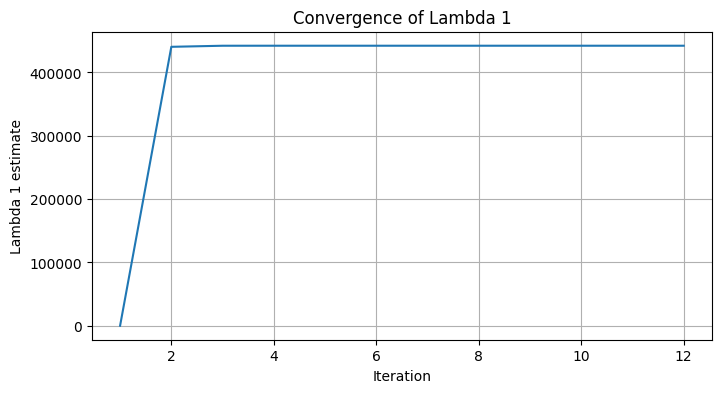

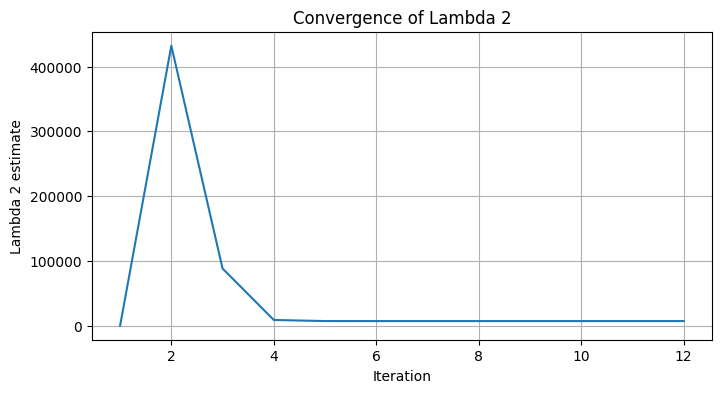

In [46]:
t = np.arange(1, len(lambda1_list) + 1)  #We can get the number of iterations by taking the length of our lambda lists


plt.figure(figsize=(8, 4))             #Plot for lambda1 against t
plt.plot(t, lambda1_list)
plt.xlabel('Iteration')
plt.ylabel('Lambda 1 estimate')
plt.title('Convergence of Lambda 1')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))             #Plot for lambda 2 against t
plt.plot(t, lambda2_list)
plt.xlabel('Iteration')
plt.ylabel('Lambda 2 estimate')
plt.title('Convergence of Lambda 2')
plt.grid(True)
plt.show()

## Projection of dataset onto eigenvectors

We now take our optiomal eigenvectors, u1 and u2 and project the centered (fixed) data onto each vector. We center the data by subtracting the mean values. Now, we take the norms of our eigenvectors, before putting them into a d x 2 matrix. We multiply this with our fixed data to get our projected n x 2 data set. Using the diagnosis Data from before we can plot our points with their color red or green, based on their classification of either 'M' or 'B' respectively.

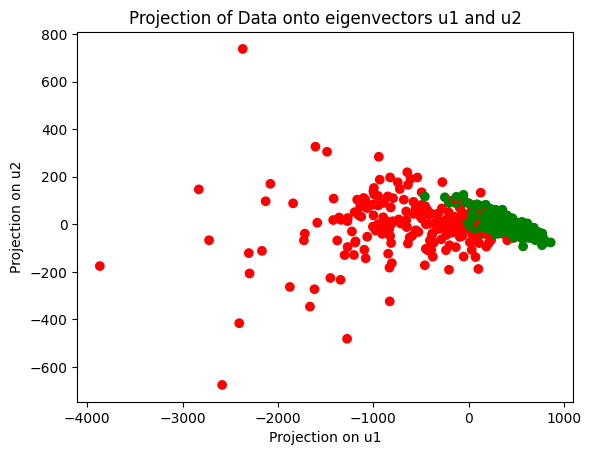

In [47]:
meanValues = np.mean(dataMatrix, axis = 0)      #First we fix our data by centering with the mean values
fixedDataMatrix = dataMatrix - meanValues   

u1 = u1 / np.linalg.norm(u1)          #Create our d x 2 matrix U, with our normalized eigenvectors
u2 = u2 / np.linalg.norm(u2)
U = np.column_stack((u1,u2))      

projDataSet = fixedDataMatrix @ U          #We project our data onto our matrix U, and get our corresponding projection on u1, proj_u1 and projection on u2, proj_u2
proj_u1 = projDataSet[:, 0]
proj_u2 = projDataSet[:, 1]

colors_list = []                           #Now, we loop through each of our samples, using our diagnosis data from before to label it
for d in diagnosisData:
    if d == 'M':
        colors_list.append('red')
    else:
        colors_list.append('green')
colors = np.array(colors_list)             #Once we have our list of colors we can make it into an array to plot

plt.xlabel("Projection on u1")             #We label our plot title and axis
plt.ylabel("Projection on u2")
plt.title("Projection of Data onto eigenvectors u1 and u2")
plt.scatter(proj_u1, proj_u2, c = colors)       #Create scatter plot with our projected data and colors
plt.show()  


## Variance Analysis

At this point we have our projected data along our eigenvectors. Now we can compute the variance of the projected points along both u1 and u2. Since we know the data was fixed, we can compute the variance by summing the squares and dividing by n - 1. Now, we compare these values to the eigenvalues computed before. Ultimately we see that the variance of the projected data along eigenvector u1 is **equal** to u1's eigenvalue. Likewise, this holds true for u2 as well. Finally, we compute the fraction of total variance captured by theses eigenvectors. The ratio is **nearly 1**, indicating that these eigenvectors captures the total variance quite well, at least relative to the random method used in the previous assignment.

In [48]:
n = fixedDataMatrix.shape[0]
var_u1 = np.sum((proj_u1)**2) / (n -1)         #We compute the variance for both u1 and u2 by summing the squared values and dividing by n - 1 
var_u2 = np.sum((proj_u2)**2) / (n -1)

totVar = np.sum(np.linalg.norm(fixedDataMatrix, axis=1)**2) / (n - 1)               #Use NumPy to sum the squared norms of our Matrix, giving us our Total Variance
ratio = (var_u1 + var_u2) / totVar                                                  #Take the ratio to be the sum of variance captured by u1 and u2 divided by total variance

print(f"Variance of projected points along u1: {var_u1}")                           #Output our computations, as well as our eigenvalues for comparison
print(f"Variance of projected points along u2: {var_u2}")
print(f"\nEigenvalue of u1: {lambda1}")
print(f"Eigenvalue of u2: {lambda2}")
print(f"\nFraction of total variance captured by two eigenvectors: {ratio}")

Variance of projected points along u1: 442188.2029190894
Variance of projected points along u2: 7169.672739995506

Eigenvalue of u1: 442188.20291908906
Eigenvalue of u2: 7169.6727399898255

Fraction of total variance captured by two eigenvectors: 0.9982251176988045


## Compare with best random projection directions

In our previous assignment 1 we used a random approach to find "best" directions. Here we use that same algorithm to get directions w1 and w2 based on this random approach. Now, we can compare the total variance to our eigenvector approach. We find that the variance is much better in the eigenvector approach, as it is over double the total variance captured, and nearly equal to 1, indicating almost full coverage. Now we find the angle between random directions w1, w2 and the corresponding eigenvectors u1, u2. Both angles are quite large, near 90 degrees, indicating the directions aren't close to each other. This explains why the variance is so far apart.

In [49]:
#The following code is copy and pasted from my first assignment.
#This is used to compute our best obtained vectors, w1 and w2, using our random approach
#We also compute the total variance captured by these two vectors for comparison

###################################################################################################################################

scaler = MinMaxScaler(feature_range = (0,1))          #Use sklearn's MinMaxScaler to fit our data between (0,1)
scaledDataMatrix = scaler.fit_transform(dataMatrix)   

meanValues = np.mean(scaledDataMatrix, axis = 0)      #Use NumPy to get means for each column in our matrix
fixedDataMatrix = scaledDataMatrix - meanValues       #Use the means we just calculated to subtract from our data, centering it about the origin.

w1 = None          #Create u1 and minMSE, which will keep track of our random vector that yields the least mean squared error
minMSE = None
for i in range(10000):           #We will go through this process 10000 times
    randVector = np.random.randn(fixedDataMatrix.shape[1])      #Use NumPy to find a random vector of d elements
    unitVector = randVector / np.linalg.norm(randVector)        #We find the unit vector of the previous random vector
    MSE = 0
    
    for x_i in fixedDataMatrix:                       #Go through each row of our matrix, calculating it's projection onto our random unit vector, and then using it to calculate the mean squared error
        p_i = np.dot(x_i, unitVector) * unitVector
        MSE += np.linalg.norm(x_i - p_i)**2
        
    if i == 0 or MSE < minMSE:                        #If this is our first iteration, or best iteration, we store the values for the unit vector and it's MSE, allowing us to track the best vector.
        w1 = unitVector
        minMSE = MSE
  
w2 = None         #Similarly, we create u2 and minMSE2 which will keep track for the orthogonal vectors
minMSE2 = None
for i in range(10000):          #We will go through this process 100000 times
    randVector = np.random.randn(fixedDataMatrix.shape[1])         #We use NumPy to find a random vector of d elements
    p_2 = np.dot(randVector, w1) * w1                              #We make that random vector orthogonal to u1
    orthoVector = randVector - p_2 
    unitVector = orthoVector / np.linalg.norm(orthoVector)         #Now we go through the same process of comparing MSE to find the "best" orthogonal vector we generate.
    MSE = 0
    
    for x_i in fixedDataMatrix:
        p_i = np.dot(x_i, unitVector) * unitVector
        MSE += np.linalg.norm(x_i - p_i)**2
        
    if i == 0 or MSE < minMSE2:
        w2 = unitVector
        minMSE2 = MSE
print(f"Smallest MSE value obtained for w1: {minMSE}")
print(f"Smallest MSE value obtained for w2: {minMSE2}")

W = np.column_stack((w1,w2))      

projWDataSet = fixedDataMatrix @ W          #We project our data onto our matrix W, and get our corresponding projection on u1, proj_u1 and projection on u2, proj_u2
proj_w1 = projWDataSet[:, 0]
proj_w2 = projWDataSet[:, 1]

n = fixedDataMatrix.shape[0]   # Number of samples
var_w1 = np.sum((proj_w1)**2) / (n -1)         #We compute the variance for both w1 and w2 by summing the squared values and dividing by n - 1 
var_w2 = np.sum((proj_w2)**2) / (n - 1)
totVar2 = np.sum(np.linalg.norm(fixedDataMatrix, axis=1)**2) / (n - 1)  #Use NumPy to sum the squared norms of our Matrix, giving us our Total Variance

Wratio = (var_w1 + var_w2) / totVar2   
###################################################################################################################################

cos_theta1 = np.dot(u1, w1) / (np.linalg.norm(u1) * np.linalg.norm(w1))   #Computing cos theta, we can get the angle between u1 and w1
angle1 = np.degrees(np.arccos(cos_theta1))

cos_theta2 = np.dot(u2, w2) / (np.linalg.norm(u2) * np.linalg.norm(w2))  #Likewise, we get the angle between u2 and w2
angle2 = np.degrees(np.arccos(cos_theta2))

print(f"\nFraction of total variance captured by two eigenvectors: {ratio}")   #We print out our variance fractions for both for comparison
print(f"Fraction of total variance captured by randomized approach: {Wratio}")

print(f"\nAngle between eigenvector u1 and search direction w1: {angle1}")   #Lastly we print out both angles we computed
print(f"Angle between eigenvector u2 and search direction w2: {angle2}")



Smallest MSE value obtained for w1: 262.6841027727611
Smallest MSE value obtained for w2: 300.6802787810443

Fraction of total variance captured by two eigenvectors: 0.9982251176988045
Fraction of total variance captured by randomized approach: 0.3988202009892794

Angle between eigenvector u1 and search direction w1: 109.98175211848132
Angle between eigenvector u2 and search direction w2: 89.48623327926329
